[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/RO/capitol3_notebook_curs.ipynb)

# Modelarea piețelor financiare — Capitolul 3: Modele factoriale și evaluarea activelor

*Notebook de curs. Daniel Traian Pele, Academia de Studii Economice din București.*

Acest notebook reproduce toate graficele și cifrele din Cursul 3:
- ETF-uri sectoriale și factoriale din SUA, SPY, blue chips de la Bursa de Valori București și BET (repository-ul cursului, `data/market`);
- factorii Fama–French, momentum și cele 25 de portofolii mărime × book-to-market (Kenneth French Data Library).

In [1]:
import os
import io
import zipfile
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Date

- ETF-uri și acțiuni: prețuri ajustate; indici (BET): valori de închidere.
- Analizele comune fac join pe **prețuri** în zilele comune, înainte de a calcula randamentele.
- Fișierele French sunt în procente: se împart la 100.

In [2]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# copia locala a folderului data/market, daca notebook-ul ruleaza din repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
FRENCH = 'https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/'

SECTORS = ['XLB', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLU', 'XLV', 'XLY']        # din dec. 1998
SECTORS_ALL = SECTORS + ['XLRE', 'XLC']                                           # XLRE 2015, XLC 2018
SECTOR_NAMES = {'XLB': 'Materials', 'XLE': 'Energy', 'XLF': 'Financials', 'XLI': 'Industrials',
                'XLK': 'Technology', 'XLP': 'Cons. staples', 'XLU': 'Utilities', 'XLV': 'Health care',
                'XLY': 'Cons. discretionary', 'XLRE': 'Real estate', 'XLC': 'Communication'}
FACTOR_ETFS = ['MTUM', 'VLUE', 'QUAL', 'USMV', 'IWM', 'IWD', 'IWF']
BVB = ['TLV', 'SNP', 'BRD', 'TGN', 'FP', 'SNG', 'H2O', 'SNN', 'EL', 'DIGI', 'TEL']
BVB_NAMES = {'TLV': 'Banca Transilvania', 'SNP': 'OMV Petrom', 'BRD': 'BRD-GSG', 'TGN': 'Transgaz',
             'FP': 'Fondul Proprietatea', 'SNG': 'Romgaz', 'H2O': 'Hidroelectrica', 'SNN': 'Nuclearelectrica',
             'EL': 'Electrica', 'DIGI': 'Digi', 'TEL': 'Transelectrica'}

_CACHE = {}


def read_market(symbol):
    """Citeste data/market/<SIMBOL>.csv local sau din repo-ul GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def price(symbol):
    """Pretul folosit: adjusted_close pentru ETF/actiuni (.US, .RO), close pentru indici."""
    d = read_market(symbol)
    col = 'close' if symbol.endswith('.INDX') or symbol == 'BET' else 'adjusted_close'
    s = d[col].astype(float)
    return s[s > 0].rename(symbol)


def prices(symbols, start=None, end=None):
    """Preturi aliniate: join pe zilele comune (analiza comuna -> intai join pe preturi)."""
    p = pd.concat([price(s) for s in symbols], axis=1).dropna()
    return p.loc[start:end]


def log_returns(p):
    """Randamente log pe un tabel deja aliniat (zile comune)."""
    return np.log(p).diff().dropna()


# =============================================================================
# KENNETH FRENCH DATA LIBRARY)
# =============================================================================
FILES = {
    ('ff5', 'M'): 'F-F_Research_Data_5_Factors_2x3_CSV.zip',
    ('ff5', 'D'): 'F-F_Research_Data_5_Factors_2x3_daily_CSV.zip',
    ('mom', 'M'): 'F-F_Momentum_Factor_CSV.zip',
    ('mom', 'D'): 'F-F_Momentum_Factor_daily_CSV.zip',
    ('p25', 'M'): '25_Portfolios_5x5_CSV.zip',
    ('ind10', 'M'): '10_Industry_Portfolios_CSV.zip',
}


def _parse_first_table(text, date_len):
    """Primul tabel din fisierul French: antet ',col1,col2...', apoi randuri YYYYMM(DD),valori."""
    lines = text.splitlines()
    i = next(k for k, l in enumerate(lines) if l.startswith(',') and len(l.split(',')) > 1)
    cols = [c.strip() for c in lines[i].split(',')[1:]]
    rows = []
    for l in lines[i + 1:]:
        parts = [x.strip() for x in l.split(',')]
        if not parts or len(parts[0]) != date_len or not parts[0].isdigit():
            break
        rows.append([parts[0]] + [float(x) for x in parts[1:]])
    df = pd.DataFrame(rows, columns=['date'] + cols)
    fmt = '%Y%m' if date_len == 6 else '%Y%m%d'
    df['date'] = pd.to_datetime(df['date'], format=fmt)
    if date_len == 6:
        df['date'] = df['date'] + pd.offsets.MonthEnd(0)
    df = df.set_index('date')
    return df.replace([-99.99, -999.0], np.nan) / 100.0          # procente -> zecimal


def french(name='ff5', freq='M'):
    """Factori Fama-French / momentum / portofolii, in zecimal (0.01 = 1%)."""
    key = (name, freq)
    if key in _CACHE:
        return _CACHE[key]
    url = FRENCH + FILES[key]
    raw = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'}),
                                 timeout=120).read()
    z = zipfile.ZipFile(io.BytesIO(raw))
    text = z.read(z.namelist()[0]).decode('latin-1')
    df = _parse_first_table(text, 6 if freq == 'M' else 8)
    df.columns = [c.replace('Mom', 'MOM').strip() for c in df.columns]
    _CACHE[key] = df
    return df


def factors(freq='M'):
    """Mkt-RF, SMB, HML, RMW, CMA, RF si MOM pe perioada comuna."""
    return pd.concat([french('ff5', freq), french('mom', freq)], axis=1).dropna()


# =============================================================================
# REGRESII
# =============================================================================
def ols_hac(y, X, lags=None, const=True):
    """OLS cu erori standard Newey-West (Bartlett). Intoarce (coef, se, t, resid, r2)."""
    y = np.asarray(y, float)
    X = np.asarray(X, float)
    if X.ndim == 1:
        X = X[:, None]
    if const:
        X = np.column_stack([np.ones(len(y)), X])
    n, k = X.shape
    if lags is None:
        lags = int(np.floor(4 * (n / 100) ** (2 / 9)))
    XtX_inv = np.linalg.inv(X.T @ X)
    b = XtX_inv @ X.T @ y
    e = y - X @ b
    u = X * e[:, None]
    S = u.T @ u
    for l in range(1, lags + 1):
        w = 1 - l / (lags + 1)
        G = u[l:].T @ u[:-l]
        S += w * (G + G.T)
    V = XtX_inv @ S @ XtX_inv
    se = np.sqrt(np.diag(V))
    r2 = 1 - e.var() / y.var()
    return b, se, b / se, e, r2


def grs_test(excess, market_excess):
    """Testul Gibbons-Ross-Shanken (1989) pentru alfa = 0 pe N active, un factor."""
    from scipy import stats
    R = np.asarray(excess, float)
    f = np.asarray(market_excess, float)
    T, N = R.shape
    X = np.column_stack([np.ones(T), f])
    B = np.linalg.lstsq(X, R, rcond=None)[0]
    alpha = B[0]
    E = R - X @ B
    Sigma = E.T @ E / (T - 2)
    mu, s2 = f.mean(), f.var(ddof=1)
    stat = (T - N - 1) / N * (alpha @ np.linalg.solve(Sigma, alpha)) / (1 + mu ** 2 / s2)
    p = 1 - stats.f.cdf(stat, N, T - N - 1)
    return stat, p, alpha, B[1]

## Stil și funcții ajutătoare

- Randamente lunare în exces: prețuri de final de lună, randamente simple minus rata titlurilor de stat la o lună (RF).
- Randamente zilnice în exces pentru un ETF: doar randamentele dintre zile de tranzacționare consecutive ale factorilor.

In [3]:
# Stil standard MFM (identic cu SFM): transparent + ENG + legenda jos
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Culori brand
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Gray     = '#7F7F7F'
LightGray = '#DADADA'
PALETTE = [MainBlue, IDAred, Forest, Amber, Orange, Purple, Crimson, '#795548', '#17A2B8', '#6F42C1', '#20C997']

SEED = 42
MAX_ABS_RET = 0.5        # prag pentru erori de date in seriile BVB (log-randament zilnic)


def save_fig(name):
    """Salveaza figura ca PDF si PNG transparent, in folderul curent."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Plaseaza legenda in afara graficului, jos-centru."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def monthly_excess(symbols, start='1999-01-01'):
    """Randamente lunare simple in exces fata de RF (T-bill la o luna), pe lunile comune."""
    p = prices(symbols).resample('ME').last()
    r = p.pct_change().dropna()
    F = factors('M')
    idx = r.index.intersection(F.index)
    r = r.loc[idx].loc[start:]
    F = F.loc[r.index]
    return r.sub(F['RF'], axis=0), F


def daily_excess_one(symbol, start=None):
    """Randamentul zilnic in exces al unui singur activ, pe calendarul factorilor.

    Se pastreaza doar zilele in care exista si pretul din ziua de tranzactionare precedenta
    (altfel randamentul ar acoperi mai multe zile, iar factorii doar una).
    """
    s = price(symbol)
    F = factors('D')
    s = s.loc[s.index.isin(F.index)]
    cal = pd.Series(np.arange(len(F)), index=F.index)
    pos = cal.loc[s.index].values
    r = s.pct_change()
    consecutive = np.r_[False, np.diff(pos) == 1]
    r = r[consecutive].dropna()
    if start:
        r = r.loc[start:]
    Fx = F.loc[r.index]
    return (r - Fx['RF']).rename(symbol), Fx


def daily_excess(symbols, start=None):
    """Compatibilitate: dictionar {simbol: (exces, factori)} pe calendarul fiecarui activ."""
    return {s: daily_excess_one(s, start) for s in symbols}


def save_fig(name):
    """Afiseaza figura."""
    plt.show()
    plt.close()

## 1. De la Markowitz la CAPM: frontiera eficientă a sectoarelor din SUA

- Portofoliul tangent $\mathbf{w} \propto \boldsymbol\Sigma^{-1}\boldsymbol\mu$; raportul Sharpe $SR = \mathbb{E}[R - R_f]/\sigma$.

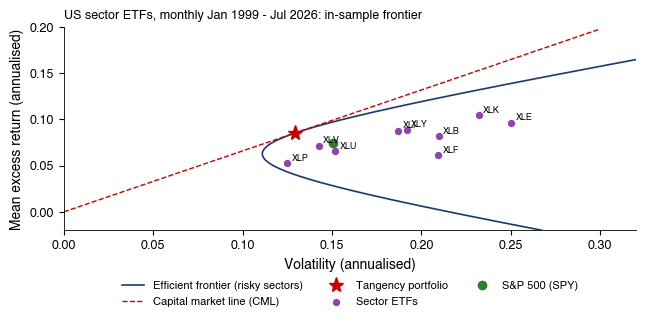

{'start': '1999-01-31',
 'end': '2026-07-31',
 'T': 331,
 'tan_mu': np.float64(0.08547106608069018),
 'tan_sd': np.float64(0.12956629364189368),
 'tan_sr': np.float64(0.6596705337340464),
 'spy_sr': np.float64(0.49319091775728513),
 'spy_mu': np.float64(0.07438851815443036),
 'spy_sd': np.float64(0.15083107874877635),
 'w_tan': {'XLB': -0.207,
  'XLE': 0.194,
  'XLF': -0.372,
  'XLI': 0.179,
  'XLK': 0.125,
  'XLP': 0.155,
  'XLU': 0.266,
  'XLV': 0.372,
  'XLY': 0.288},
 'w_neg': 2}

In [4]:
def fig_frontier():
    S = [s + '.US' for s in SECTORS]
    ex, F = monthly_excess(S + ['SPY.US'])
    mu = ex[S].mean().values * 12
    cov = ex[S].cov().values * 12
    ones = np.ones(len(S))
    inv = np.linalg.inv(cov)
    w_tan = inv @ mu / (ones @ inv @ mu)
    mu_t, sd_t = w_tan @ mu, np.sqrt(w_tan @ cov @ w_tan)
    # frontiera (fara restrictii) in spatiul excesului de randament
    A, B, C = ones @ inv @ ones, ones @ inv @ mu, mu @ inv @ mu
    targets = np.linspace(-0.02, 0.20, 200)
    sd_f = np.sqrt((A * targets ** 2 - 2 * B * targets + C) / (A * C - B ** 2))
    fig, ax = plt.subplots(figsize=(6.6, 3.4))
    ax.plot(sd_f, targets, color=MainBlue, lw=1.2, label='Efficient frontier (risky sectors)')
    xs = np.linspace(0, 0.30, 50)
    ax.plot(xs, mu_t / sd_t * xs, color=IDAred, lw=1.0, ls='--', label='Capital market line (CML)')
    ax.plot(sd_t, mu_t, '*', ms=11, color=IDAred, label='Tangency portfolio')
    sd_i = np.sqrt(np.diag(cov))
    ax.scatter(sd_i, mu, s=18, color=Purple, zorder=3, label='Sector ETFs')
    for s, x, y in zip(SECTORS, sd_i, mu):
        ax.annotate(s, (x, y), xytext=(3, 2), textcoords='offset points', fontsize=6.5, color='black')
    spy_mu, spy_sd = ex['SPY.US'].mean() * 12, ex['SPY.US'].std() * np.sqrt(12)
    ax.plot(spy_sd, spy_mu, 'o', ms=6, color=Forest, label='S&P 500 (SPY)')
    ax.set_xlim(0, 0.32)
    ax.set_ylim(-0.02, 0.20)
    ax.set_xlabel('Volatility (annualised)')
    ax.set_ylabel('Mean excess return (annualised)')
    ax.set_title(f'US sector ETFs, monthly {ex.index[0]:%b %Y} - {ex.index[-1]:%b %Y}: in-sample frontier',
                 fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=3, y=-0.2)
    plt.tight_layout()
    save_fig('ch3_frontier')
    w = pd.Series(w_tan, index=SECTORS)
    return dict(start=str(ex.index[0].date()), end=str(ex.index[-1].date()), T=len(ex),
                tan_mu=mu_t, tan_sd=sd_t, tan_sr=mu_t / sd_t, spy_sr=spy_mu / spy_sd,
                spy_mu=spy_mu, spy_sd=spy_sd, w_tan=w.round(3).to_dict(),
                w_neg=int((w < 0).sum()))


fig_frontier()

## 2. Estimarea lui beta

- Beta rulant pe 252 de zile; ajustările Blume și Vasicek; blue chips BVB față de BET.

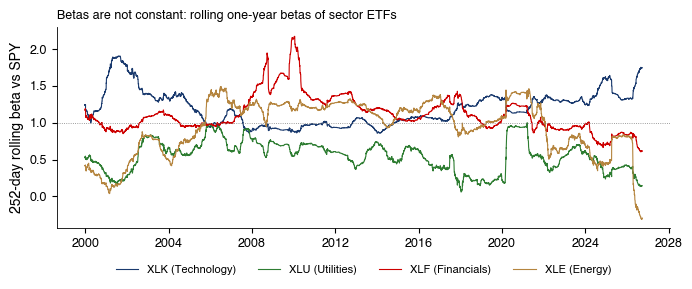

{'XLK': {'min': 0.8571078937477423,
  'max': 1.9043987052314573,
  'last': 1.7455945184598844},
 'XLU': {'min': 0.059145441320352814,
  'max': 0.9997646407325816,
  'last': 0.1467223231886952},
 'XLF': {'min': 0.6041280413283017,
  'max': 2.171711568839296,
  'last': 0.6141389301949327},
 'XLE': {'min': -0.30989154058061164,
  'max': 1.4896376606943942,
  'last': -0.291595900605115}}

In [5]:
def fig_rolling_beta(window=252):
    S = ['XLK.US', 'XLU.US', 'XLF.US', 'XLE.US']
    r = log_returns(prices(S + ['SPY.US']))
    m = r['SPY.US']
    fig, ax = plt.subplots(figsize=(7.0, 3.0))
    out = {}
    for s, c in zip(S, [MainBlue, Forest, IDAred, Amber]):
        b = r[s].rolling(window).cov(m) / m.rolling(window).var()
        ax.plot(b.index, b.values, color=c, lw=0.8, label=f'{s[:-3]} ({SECTOR_NAMES[s[:-3]]})')
        out[s[:-3]] = dict(min=float(b.min()), max=float(b.max()), last=float(b.dropna().iloc[-1]))
    ax.axhline(1, color=Gray, lw=0.6, ls=':')
    ax.set_ylabel('252-day rolling beta vs SPY')
    ax.set_title('Betas are not constant: rolling one-year betas of sector ETFs', fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=4, y=-0.13)
    plt.tight_layout()
    save_fig('ch3_rolling_beta')
    return out


fig_rolling_beta()

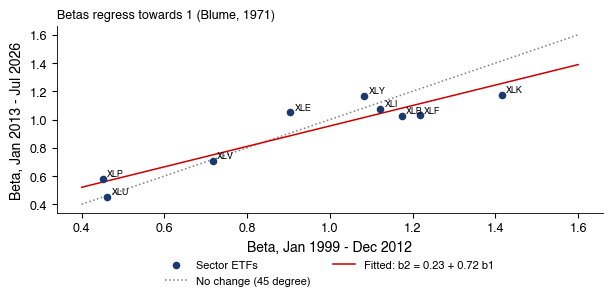

{'slope': np.float64(0.7241724887901937),
 'icpt': np.float64(0.23044793303727698),
 'rmse_raw': 0.13471984494507508,
 'rmse_blume': 0.10925855446576165,
 'rmse_vasicek': 0.11478364969483217,
 'prior_mean': np.float64(0.9494604188301623),
 'betas1': {'XLB': 1.174,
  'XLE': 0.904,
  'XLF': 1.217,
  'XLI': 1.122,
  'XLK': 1.415,
  'XLP': 0.451,
  'XLU': 0.463,
  'XLV': 0.716,
  'XLY': 1.083},
 'betas2': {'XLB': 1.026,
  'XLE': 1.051,
  'XLF': 1.029,
  'XLI': 1.078,
  'XLK': 1.172,
  'XLP': 0.578,
  'XLU': 0.455,
  'XLV': 0.705,
  'XLY': 1.169},
 'vasicek': {'XLB': 1.162,
  'XLE': 0.907,
  'XLF': 1.187,
  'XLI': 1.117,
  'XLK': 1.348,
  'XLP': 0.468,
  'XLU': 0.492,
  'XLV': 0.721,
  'XLY': 1.078}}

In [6]:
def beta_split():
    S = [s + '.US' for s in SECTORS]
    ex, F = monthly_excess(S + ['SPY.US'])
    halves = [ex.loc[:'2012-12-31'], ex.loc['2013-01-01':]]
    b = []
    for h in halves:
        b.append(pd.Series({s[:-3]: ols_hac(h[s].values, h['SPY.US'].values)[0][1] for s in S}))
    se1 = pd.Series({s[:-3]: ols_hac(halves[0][s].values, halves[0]['SPY.US'].values)[1][1] for s in S})
    return b[0], b[1], se1, halves


def fig_beta_shrink():
    b1, b2, se1, halves = beta_split()
    slope, icpt = np.polyfit(b1, b2, 1)
    # Vasicek: media si dispersia cross-sectionala a beta ca informatie a priori
    prior_m, prior_v = b1.mean(), b1.var(ddof=1)
    w = prior_v / (prior_v + se1 ** 2)
    b_vas = w * b1 + (1 - w) * prior_m
    b_blume = 0.67 * b1 + 0.33
    err = lambda x: float(np.sqrt(((x - b2) ** 2).mean()))
    fig, ax = plt.subplots(figsize=(6.2, 3.2))
    ax.scatter(b1, b2, s=20, color=MainBlue, zorder=3, label='Sector ETFs')
    for s in b1.index:
        ax.annotate(s, (b1[s], b2[s]), xytext=(3, 2), textcoords='offset points', fontsize=6.5, color='black')
    xs = np.linspace(0.4, 1.6, 10)
    ax.plot(xs, xs, color=Gray, ls=':', label='No change (45 degree)')
    ax.plot(xs, icpt + slope * xs, color=IDAred, label=f'Fitted: b2 = {icpt:.2f} + {slope:.2f} b1')
    ax.set_xlabel('Beta, Jan 1999 - Dec 2012')
    ax.set_ylabel('Beta, Jan 2013 - Jul 2026')
    ax.set_title('Betas regress towards 1 (Blume, 1971)', fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=2, y=-0.2)
    plt.tight_layout()
    save_fig('ch3_beta_shrink')
    return dict(slope=slope, icpt=icpt, rmse_raw=err(b1), rmse_blume=err(b_blume), rmse_vasicek=err(b_vas),
                prior_mean=prior_m, betas1=b1.round(3).to_dict(), betas2=b2.round(3).to_dict(),
                vasicek=b_vas.round(3).to_dict())


fig_beta_shrink()

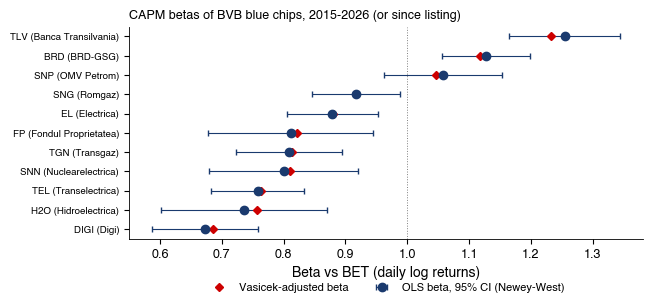

[{'stock': 'DIGI',
  'beta': 0.673,
  'se': 0.044,
  'r2': 0.208,
  'n': 2326,
  'from': '2017-05-18',
  'n_removed': 1,
  'vasicek': 0.686},
 {'stock': 'H2O',
  'beta': 0.737,
  'se': 0.069,
  'r2': 0.313,
  'n': 792,
  'from': '2023-07-13',
  'n_removed': 0,
  'vasicek': 0.756},
 {'stock': 'TEL',
  'beta': 0.758,
  'se': 0.039,
  'r2': 0.245,
  'n': 2925,
  'from': '2015-01-06',
  'n_removed': 0,
  'vasicek': 0.764},
 {'stock': 'SNN',
  'beta': 0.8,
  'se': 0.061,
  'r2': 0.29,
  'n': 2925,
  'from': '2015-01-06',
  'n_removed': 0,
  'vasicek': 0.81},
 {'stock': 'TGN',
  'beta': 0.809,
  'se': 0.044,
  'r2': 0.3,
  'n': 2925,
  'from': '2015-01-06',
  'n_removed': 0,
  'vasicek': 0.813},
 {'stock': 'FP',
  'beta': 0.811,
  'se': 0.068,
  'r2': 0.328,
  'n': 2923,
  'from': '2015-01-06',
  'n_removed': 2,
  'vasicek': 0.822},
 {'stock': 'EL',
  'beta': 0.879,
  'se': 0.038,
  'r2': 0.3,
  'n': 2925,
  'from': '2015-01-06',
  'n_removed': 0,
  'vasicek': 0.879},
 {'stock': 'SNG',
  'be

In [7]:
def bvb_betas(start='2015-01-01'):
    rows = []
    for s in BVB:
        p = prices([s + '.RO', 'BET']).loc[start:]
        r = log_returns(p)
        # erori de date (evenimente de capital neajustate): |r| > 50% intr-o zi se elimina
        bad = (r.abs() > MAX_ABS_RET).any(axis=1)
        r = r[~bad]
        b, se, t, e, r2 = ols_hac(r[s + '.RO'].values, r['BET'].values)
        rows.append((s, b[1], se[1], r2, len(r), str(r.index[0].date()), int(bad.sum())))
    res = pd.DataFrame(rows, columns=['stock', 'beta', 'se', 'r2', 'n', 'from', 'n_removed']).set_index('stock')
    prior_m, prior_v = res['beta'].mean(), res['beta'].var(ddof=1)
    w = prior_v / (prior_v + res['se'] ** 2)
    res['vasicek'] = w * res['beta'] + (1 - w) * prior_m
    return res.sort_values('beta')


def fig_bvb_betas():
    res = bvb_betas()
    y = np.arange(len(res))
    fig, ax = plt.subplots(figsize=(6.6, 3.2))
    ax.errorbar(res['beta'], y, xerr=1.96 * res['se'], fmt='o', color=MainBlue, capsize=2, lw=0.8,
                label='OLS beta, 95% CI (Newey-West)')
    ax.plot(res['vasicek'], y, 'D', ms=4, color=IDAred, label='Vasicek-adjusted beta')
    ax.axvline(1, color=Gray, ls=':', lw=0.7)
    ax.set_yticks(y, [f'{s} ({BVB_NAMES[s]})' for s in res.index], fontsize=7)
    ax.set_xlabel('Beta vs BET (daily log returns)')
    ax.set_title('CAPM betas of BVB blue chips, 2015-2026 (or since listing)', fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=2, y=-0.16)
    plt.tight_layout()
    save_fig('ch3_bvb_betas')
    return res.round(3).reset_index().to_dict(orient='records')


fig_bvb_betas()

## 3. Testarea CAPM: dreapta titlurilor și testul GRS

- 25 de portofolii mărime × book-to-market, lunar 1963–2026; $W = \frac{T-N-1}{N}\frac{\hat\alpha'\hat\Sigma^{-1}\hat\alpha}{1+\hat\mu_m^2/\hat\sigma_m^2}$.

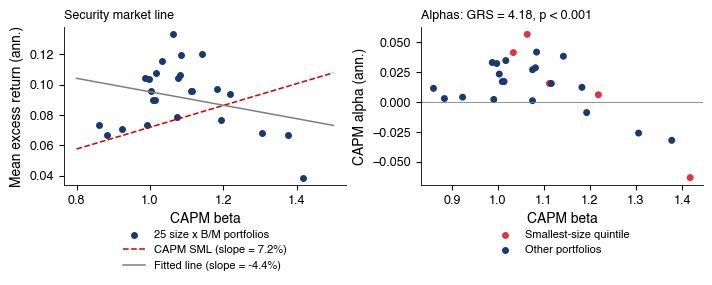

{'start': '1963-07-31',
 'end': '2026-07-31',
 'T': 757,
 'prem': np.float64(0.07190805812417439),
 'slope': np.float64(-0.0443750687787674),
 'icpt': np.float64(0.1397079301946724),
 'beta_min': 0.8600514139934057,
 'beta_max': 1.4175444293091366,
 'avg_min': 0.03866495112285337,
 'avg_max': 0.1332374425363276,
 'grs': np.float64(4.184410570498348),
 'grs_p': np.float64(8.271294760220371e-11),
 'n_sig': 10,
 'alpha_smallvalue': np.float64(0.056745711698739675),
 'alpha_smallgrowth': np.float64(-0.06326791609350756)}

In [8]:
def sml_data(start='1963-07-31'):
    F = factors('M')
    P = french('p25', 'M').loc[start:F.index[-1]]
    Fx = F.loc[P.index]
    ex = P.sub(Fx['RF'], axis=0)
    mk = Fx['Mkt-RF']
    rows = []
    for c in ex.columns:
        b, se, t, e, r2 = ols_hac(ex[c].values, mk.values)
        rows.append((c, b[1], b[0] * 12, t[0], ex[c].mean() * 12))
    res = pd.DataFrame(rows, columns=['port', 'beta', 'alpha', 't_alpha', 'avg']).set_index('port')
    return res, ex, mk


def fig_sml():
    res, ex, mk = sml_data()
    prem = mk.mean() * 12
    slope, icpt = np.polyfit(res['beta'], res['avg'], 1)
    stat, pv, _, _ = grs_test(ex.values, mk.values)
    small = [c for c in res.index if c.startswith('SMALL') or c.startswith('ME1')]
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.1))
    ax = axes[0]
    ax.scatter(res['beta'], res['avg'], s=16, color=MainBlue, label='25 size x B/M portfolios')
    xs = np.linspace(0.8, 1.5, 10)
    ax.plot(xs, prem * xs, color=IDAred, ls='--', label=f'CAPM SML (slope = {prem:.1%})')
    ax.plot(xs, icpt + slope * xs, color=Gray, label=f'Fitted line (slope = {slope:.1%})')
    ax.set_xlabel('CAPM beta')
    ax.set_ylabel('Mean excess return (ann.)')
    ax.set_title('Security market line', fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=1, y=-0.22)
    ax = axes[1]
    col = [Crimson if c in small else MainBlue for c in res.index]
    ax.scatter(res['beta'], res['alpha'], s=16, c=col)
    ax.axhline(0, color=Gray, lw=0.6)
    ax.set_xlabel('CAPM beta')
    ax.set_ylabel('CAPM alpha (ann.)')
    ax.set_title(f'Alphas: GRS = {stat:.2f}, p < 0.001', fontsize=9, loc='left')
    ax.scatter([], [], s=16, color=Crimson, label='Smallest-size quintile')
    ax.scatter([], [], s=16, color=MainBlue, label='Other portfolios')
    legend_outside_bottom(ax, ncol=1, y=-0.22)
    plt.tight_layout()
    save_fig('ch3_sml')
    return dict(start=str(ex.index[0].date()), end=str(ex.index[-1].date()), T=len(ex), prem=prem,
                slope=slope, icpt=icpt, beta_min=res['beta'].min(), beta_max=res['beta'].max(),
                avg_min=res['avg'].min(), avg_max=res['avg'].max(), grs=stat, grs_p=pv,
                n_sig=int((res['t_alpha'].abs() > 1.96).sum()),
                alpha_smallvalue=res.loc['SMALL HiBM', 'alpha'], alpha_smallgrowth=res.loc['SMALL LoBM', 'alpha'])


fig_sml()

## 4. Regresii Fama–MacBeth

- Etapa 1: beta din serii de timp; Etapa 2: pante transversale lunare, mediate.
- Erori standard: Fama–MacBeth, Newey–West (6 laguri) și Shanken.

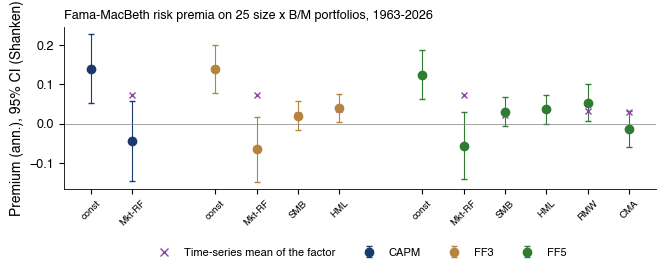

{'CAPM': [{'index': 'const',
   'lambda': 0.1397,
   'se_fm': 0.0444,
   'se_nw': 0.0479,
   'se_shanken': 0.0444,
   'factor_mean': nan},
  {'index': 'Mkt-RF',
   'lambda': -0.0444,
   'se_fm': 0.0477,
   'se_nw': 0.0514,
   'se_shanken': 0.0517,
   'factor_mean': 0.0719}],
 'FF3': [{'index': 'const',
   'lambda': 0.1383,
   'se_fm': 0.0311,
   'se_nw': 0.0321,
   'se_shanken': 0.0311,
   'factor_mean': nan},
  {'index': 'Mkt-RF',
   'lambda': -0.0656,
   'se_fm': 0.0366,
   'se_nw': 0.0359,
   'se_shanken': 0.042,
   'factor_mean': 0.0719},
  {'index': 'SMB',
   'lambda': 0.0201,
   'se_fm': 0.0137,
   'se_nw': 0.0144,
   'se_shanken': 0.0192,
   'factor_mean': 0.0225},
  {'index': 'HML',
   'lambda': 0.0396,
   'se_fm': 0.0133,
   'se_nw': 0.0162,
   'se_shanken': 0.0187,
   'factor_mean': 0.0359}],
 'FF5': [{'index': 'const',
   'lambda': 0.1243,
   'se_fm': 0.0314,
   'se_nw': 0.0298,
   'se_shanken': 0.0314,
   'factor_mean': nan},
  {'index': 'Mkt-RF',
   'lambda': -0.0565,
   '

In [9]:
def fama_macbeth(ex, F, fac, nw_lags=6):
    """Prima etapa: beta pe toata perioada; a doua: regresii transversale lunare."""
    X = F[fac].values
    B = np.linalg.lstsq(np.column_stack([np.ones(len(X)), X]), ex.values, rcond=None)[0][1:].T   # N x K
    lam = []
    for t in range(len(ex)):
        Z = np.column_stack([np.ones(B.shape[0]), B])
        lam.append(np.linalg.lstsq(Z, ex.values[t], rcond=None)[0])
    lam = np.array(lam)                                   # T x (1+K)
    mean = lam.mean(0)
    se_fm = lam.std(0, ddof=1) / np.sqrt(len(lam))
    se_nw = np.array([ols_hac(lam[:, j], np.zeros((len(lam), 0)), lags=nw_lags)[1][0] for j in range(lam.shape[1])])
    # corectia Shanken (1992): (1 + lambda' Sigma_f^-1 lambda) pentru termenii de prima
    Sf = np.atleast_2d(np.cov(X.T))
    c = 1 + mean[1:] @ np.linalg.solve(Sf, mean[1:])
    se_sh = se_fm.copy()
    se_sh[1:] = np.sqrt(se_fm[1:] ** 2 * c + np.diag(Sf) / len(lam))
    return pd.DataFrame({'lambda': mean * 12, 'se_fm': se_fm * 12, 'se_nw': se_nw * 12, 'se_shanken': se_sh * 12,
                         'factor_mean': np.r_[np.nan, X.mean(0) * 12]}, index=['const'] + fac)


def fig_fama_macbeth():
    res, ex, mk = sml_data()
    F = factors('M').loc[ex.index]
    models = {'CAPM': ['Mkt-RF'], 'FF3': ['Mkt-RF', 'SMB', 'HML'], 'FF5': ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']}
    out = {k: fama_macbeth(ex, F, v) for k, v in models.items()}
    fig, ax = plt.subplots(figsize=(6.8, 3.0))
    labels, x0 = [], 0
    for k, c in zip(models, [MainBlue, Amber, Forest]):
        d = out[k]
        xs = np.arange(len(d)) + x0
        ax.errorbar(xs, d['lambda'], yerr=1.96 * d['se_shanken'], fmt='o', color=c, capsize=2, lw=0.8, label=k)
        ax.plot(xs[1:], d['factor_mean'].iloc[1:], 'x', color=Purple, ms=5)
        labels += [f'{k}: {n}' for n in d.index]
        x0 += len(d) + 1
    ax.plot([], [], 'x', color=Purple, label='Time-series mean of the factor')
    ax.axhline(0, color=Gray, lw=0.5)
    ticks = []
    x0 = 0
    for k in models:
        ticks += list(np.arange(len(out[k])) + x0)
        x0 += len(out[k]) + 1
    ax.set_xticks(ticks, [l.split(': ')[1] for l in labels], rotation=45, fontsize=7)
    ax.set_ylabel('Premium (ann.), 95% CI (Shanken)')
    ax.set_title('Fama-MacBeth risk premia on 25 size x B/M portfolios, 1963-2026', fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=4, y=-0.3)
    plt.tight_layout()
    save_fig('ch3_fama_macbeth')
    return {k: v.round(4).reset_index().to_dict(orient='records') for k, v in out.items()}


fig_fama_macbeth()

## 5. Modele multifactoriale: șase factori din 1963

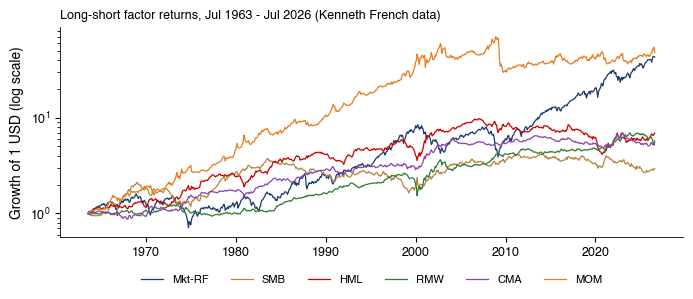

{'Mkt-RF': 43.16818094955181,
 'SMB': 2.928401073953682,
 'HML': 6.881711823776164,
 'RMW': 5.73288196476011,
 'CMA': 5.490563256760096,
 'MOM': 47.951970255306136}

In [10]:
def fig_factor_cum():
    F = factors('M')
    cols = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'MOM']
    fig, ax = plt.subplots(figsize=(7.0, 3.1))
    out = {}
    for c, col in zip(cols, [MainBlue, Amber, IDAred, Forest, Purple, Orange]):
        wealth = (1 + F[c]).cumprod()
        ax.plot(wealth.index, wealth.values, color=col, lw=0.9, label=c)
        out[c] = float(wealth.iloc[-1])
    ax.set_yscale('log')
    ax.set_ylabel('Growth of 1 USD (log scale)')
    ax.set_title(f'Long-short factor returns, {F.index[0]:%b %Y} - {F.index[-1]:%b %Y} (Kenneth French data)',
                 fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=6, y=-0.13)
    plt.tight_layout()
    save_fig('ch3_factor_cum')
    return out


fig_factor_cum()

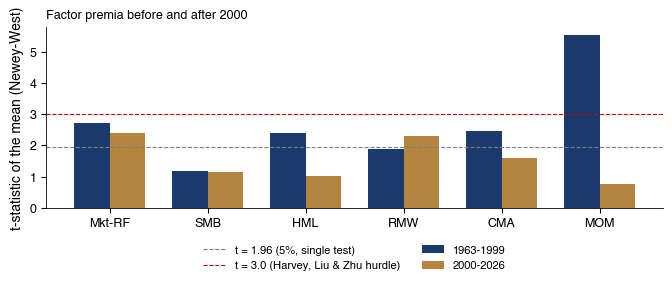

,factor,period,mean,t
0,Mkt-RF,1963-1999,0.069721,2.704993
1,Mkt-RF,2000-2026,0.074912,2.386159
2,SMB,1963-1999,0.023249,1.186117
3,SMB,2000-2026,0.021419,1.140869
4,HML,1963-1999,0.041915,2.394773
5,HML,2000-2026,0.027600,1.018865
6,RMW,1963-1999,0.020715,1.896612
7,RMW,2000-2026,0.044765,2.306372
8,CMA,1963-1999,0.031085,2.475194
9,CMA,2000-2026,0.027532,1.596993


In [11]:
def factor_tstats(split='1999-12-31'):
    F = factors('M')
    cols = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'MOM']
    rows = []
    for c in cols:
        for lab, x in [('1963-1999', F[c].loc[:split]), ('2000-2026', F[c].loc[split:].iloc[1:])]:
            b, se, t, _, _ = ols_hac(x.values, np.zeros((len(x), 0)))
            rows.append((c, lab, x.mean() * 12, t[0]))
    return pd.DataFrame(rows, columns=['factor', 'period', 'mean', 't'])


def fig_factor_tstats():
    d = factor_tstats()
    cols = d['factor'].unique()
    x = np.arange(len(cols))
    fig, ax = plt.subplots(figsize=(6.8, 3.0))
    for k, (lab, c) in enumerate([('1963-1999', MainBlue), ('2000-2026', Amber)]):
        v = d[d['period'] == lab].set_index('factor').loc[cols, 't']
        ax.bar(x + (k - 0.5) * 0.36, v.values, 0.36, color=c, label=lab)
    ax.axhline(1.96, color=Gray, ls='--', lw=0.8, label='t = 1.96 (5%, single test)')
    ax.axhline(3.0, color=IDAred, ls='--', lw=0.8, label='t = 3.0 (Harvey, Liu & Zhu hurdle)')
    ax.axhline(0, color=Gray, lw=0.5)
    ax.set_xticks(x, cols)
    ax.set_ylabel('t-statistic of the mean (Newey-West)')
    ax.set_title('Factor premia before and after 2000', fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=2, y=-0.15)
    plt.tight_layout()
    save_fig('ch3_factor_tstats')
    return d


fig_factor_tstats()

## 6. Grădina zoologică a factorilor: 300 de factori inutili

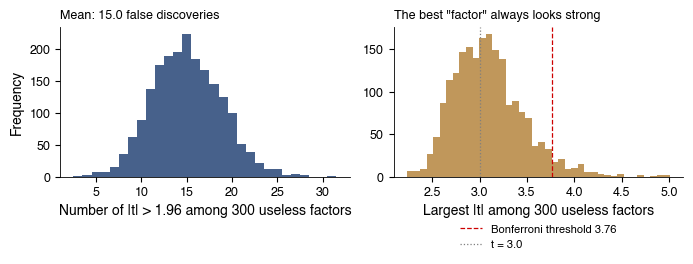

{'M': 300,
 'mean_n196': 15.0175,
 'mean_n3': 0.832,
 'median_tmax': 3.057760553531356,
 'bonf': 3.764823649533926,
 'p_any3': 0.5695}

In [12]:
def fig_false_discoveries(M=300, T=600, reps=2000):
    rng = np.random.default_rng(SEED)
    # M factori fara prima (media 0), fiecare testat pe T luni
    t = rng.standard_normal((reps, M))                 # statistica t ~ N(0,1) sub H0, teste independente
    n196 = (np.abs(t) > 1.96).sum(1)
    n3 = (np.abs(t) > 3.0).sum(1)
    tmax = np.abs(t).max(1)
    bonf = stats.norm.ppf(1 - 0.05 / (2 * M))
    fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.9))
    axes[0].hist(n196, bins=np.arange(n196.min(), n196.max() + 2) - 0.5, color=MainBlue, alpha=0.8)
    axes[0].set_xlabel('Number of |t| > 1.96 among 300 useless factors')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title(f'Mean: {n196.mean():.1f} false discoveries', fontsize=9, loc='left')
    axes[1].hist(tmax, bins=40, color=Amber, alpha=0.85)
    axes[1].axvline(bonf, color=IDAred, ls='--', lw=0.9, label=f'Bonferroni threshold {bonf:.2f}')
    axes[1].axvline(3.0, color=Gray, ls=':', lw=0.9, label='t = 3.0')
    axes[1].set_xlabel('Largest |t| among 300 useless factors')
    axes[1].set_title('The best "factor" always looks strong', fontsize=9, loc='left')
    legend_outside_bottom(axes[1], ncol=1, y=-0.25)
    plt.tight_layout()
    save_fig('ch3_false_discoveries')
    return dict(M=M, mean_n196=float(n196.mean()), mean_n3=float(n3.mean()), median_tmax=float(np.median(tmax)),
                bonf=float(bonf), p_any3=float((n3 > 0).mean()))


fig_false_discoveries()

## 7. Factori latenți: PCA pe ETF-urile sectoriale din SUA

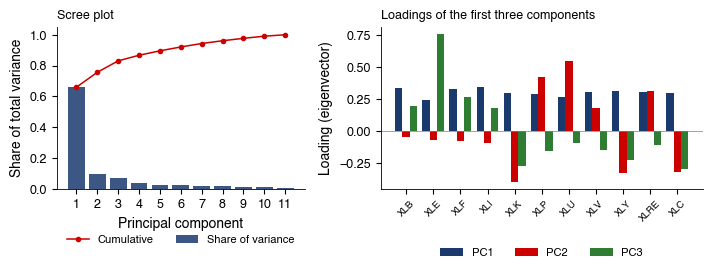

{'start': '2018-06-20',
 'end': '2026-09-18',
 'T': 2073,
 'share': [0.6598485852014292,
  0.0967418826785423,
  0.0742696512685773,
  0.036276040707513814,
  0.028787802265608294],
 'cum3': 0.8308601191485488,
 'corr_pc1_spy': 0.9539639295054083,
 'load_pc2': {'XLB': np.float64(-0.051),
  'XLE': np.float64(-0.072),
  'XLF': np.float64(-0.078),
  'XLI': np.float64(-0.096),
  'XLK': np.float64(-0.398),
  'XLP': np.float64(0.418),
  'XLU': np.float64(0.549),
  'XLV': np.float64(0.176),
  'XLY': np.float64(-0.332),
  'XLRE': np.float64(0.309),
  'XLC': np.float64(-0.326)},
 'load_pc1': {'XLB': np.float64(0.332),
  'XLE': np.float64(0.241),
  'XLF': np.float64(0.329),
  'XLI': np.float64(0.339),
  'XLK': np.float64(0.293),
  'XLP': np.float64(0.285),
  'XLU': np.float64(0.262),
  'XLV': np.float64(0.303),
  'XLY': np.float64(0.313),
  'XLRE': np.float64(0.307),
  'XLC': np.float64(0.299)}}

In [13]:
def pca_sectors():
    S = [s + '.US' for s in SECTORS_ALL]
    r = log_returns(prices(S + ['SPY.US']))
    X = r[S]
    Z = (X - X.mean()) / X.std()
    C = np.corrcoef(Z.values.T)
    vals, vecs = np.linalg.eigh(C)
    order = np.argsort(vals)[::-1]
    vals, vecs = vals[order], vecs[:, order]
    for k in range(vecs.shape[1]):                      # semn: incarcare medie pozitiva
        if vecs[:, k].sum() < 0:
            vecs[:, k] *= -1
    pcs = Z.values @ vecs
    corr_pc1_spy = np.corrcoef(pcs[:, 0], r['SPY.US'].values)[0, 1]
    return vals, vecs, r, corr_pc1_spy


def fig_pca():
    vals, vecs, r, c1 = pca_sectors()
    share = vals / vals.sum()
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.0), gridspec_kw={'width_ratios': [1, 1.3]})
    k = np.arange(1, len(vals) + 1)
    axes[0].bar(k, share, color=MainBlue, alpha=0.85, label='Share of variance')
    axes[0].plot(k, np.cumsum(share), color=IDAred, marker='o', ms=3, label='Cumulative')
    axes[0].set_xlabel('Principal component')
    axes[0].set_ylabel('Share of total variance')
    axes[0].set_xticks(k)
    axes[0].set_title('Scree plot', fontsize=9, loc='left')
    legend_outside_bottom(axes[0], ncol=2, y=-0.22)
    x = np.arange(len(SECTORS_ALL))
    for j, c in enumerate([MainBlue, IDAred, Forest]):
        axes[1].bar(x + (j - 1) * 0.27, vecs[:, j], 0.27, color=c, label=f'PC{j + 1}')
    axes[1].axhline(0, color=Gray, lw=0.5)
    axes[1].set_xticks(x, SECTORS_ALL, rotation=45, fontsize=7)
    axes[1].set_ylabel('Loading (eigenvector)')
    axes[1].set_title('Loadings of the first three components', fontsize=9, loc='left')
    legend_outside_bottom(axes[1], ncol=3, y=-0.3)
    plt.tight_layout()
    save_fig('ch3_pca')
    return dict(start=str(r.index[0].date()), end=str(r.index[-1].date()), T=len(r),
                share=[float(s) for s in share[:5]], cum3=float(share[:3].sum()), corr_pc1_spy=float(c1),
                load_pc2=dict(zip(SECTORS_ALL, np.round(vecs[:, 1], 3))),
                load_pc1=dict(zip(SECTORS_ALL, np.round(vecs[:, 0], 3))))


fig_pca()

## 8. Investiții factoriale: ETF-uri factoriale, evoluția și valorile lor alfa

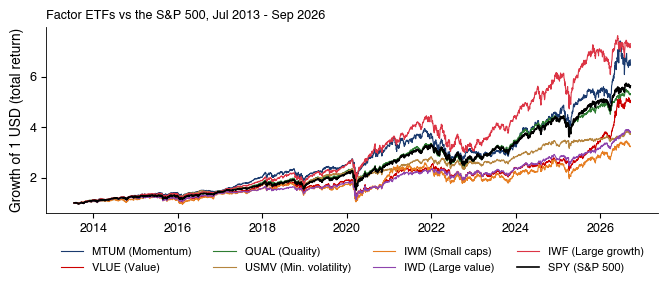

{'start': '2013-07-18',
 'cagr': {'MTUM': 0.15501271636210756,
  'VLUE': 0.13090712217448797,
  'QUAL': 0.13542910146314502,
  'USMV': 0.10500583723814261,
  'IWM': 0.09322036712947179,
  'IWD': 0.1069093487845969,
  'IWF': 0.16313245149221034,
  'SPY': 0.14036040990013188}}

In [14]:
def fig_factor_etfs():
    E = [e + '.US' for e in FACTOR_ETFS] + ['SPY.US']
    p = prices(E)
    wealth = p / p.iloc[0]
    fig, ax = plt.subplots(figsize=(7.0, 3.0))
    names = {'MTUM': 'Momentum', 'VLUE': 'Value', 'QUAL': 'Quality', 'USMV': 'Min. volatility',
             'IWM': 'Small caps', 'IWD': 'Large value', 'IWF': 'Large growth', 'SPY': 'S&P 500'}
    out = {}
    for e, c in zip(E, PALETTE):
        k = e[:-3]
        ax.plot(wealth.index, wealth[e].values, color=c if k != 'SPY' else 'black', lw=0.8 if k != 'SPY' else 1.2,
                label=f'{k} ({names[k]})')
        yrs = (p.index[-1] - p.index[0]).days / 365.25
        out[k] = float(wealth[e].iloc[-1] ** (1 / yrs) - 1)
    ax.set_ylabel('Growth of 1 USD (total return)')
    ax.set_title(f'Factor ETFs vs the S&P 500, {p.index[0]:%b %Y} - {p.index[-1]:%b %Y}', fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=4, y=-0.13)
    plt.tight_layout()
    save_fig('ch3_factor_etfs')
    return dict(start=str(p.index[0].date()), cagr=out)


fig_factor_etfs()

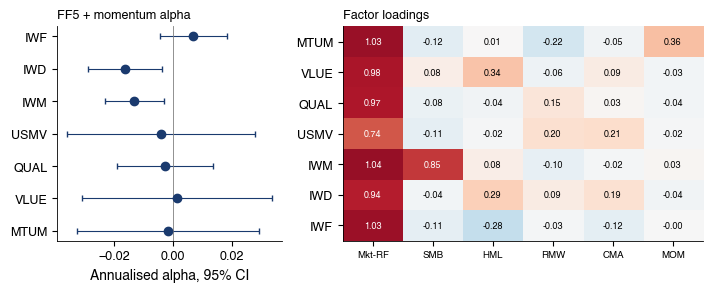

{'start': '2000-05-30',
 'end': '2026-07-31',
 'n_min': 3194,
 'n_max': 6582,
 'table': [{'etf': 'MTUM',
   'alpha': -0.002,
   'se_alpha': 0.016,
   't_alpha': -0.111,
   'r2': 0.905,
   'n': 3338,
   'Mkt-RF': 1.034,
   'SMB': -0.123,
   'HML': 0.008,
   'RMW': -0.221,
   'CMA': -0.046,
   'MOM': 0.36},
  {'etf': 'VLUE',
   'alpha': 0.001,
   'se_alpha': 0.016,
   't_alpha': 0.078,
   'r2': 0.886,
   'n': 3194,
   'Mkt-RF': 0.983,
   'SMB': 0.076,
   'HML': 0.342,
   'RMW': -0.064,
   'CMA': 0.094,
   'MOM': -0.035},
  {'etf': 'QUAL',
   'alpha': -0.003,
   'se_alpha': 0.008,
   't_alpha': -0.342,
   'r2': 0.963,
   'n': 3276,
   'Mkt-RF': 0.975,
   'SMB': -0.078,
   'HML': -0.044,
   'RMW': 0.145,
   'CMA': 0.025,
   'MOM': -0.037},
  {'etf': 'USMV',
   'alpha': -0.004,
   'se_alpha': 0.016,
   't_alpha': -0.254,
   'r2': 0.81,
   'n': 3703,
   'Mkt-RF': 0.742,
   'SMB': -0.105,
   'HML': -0.017,
   'RMW': 0.196,
   'CMA': 0.211,
   'MOM': -0.015},
  {'etf': 'IWM',
   'alpha': -0.01

In [15]:
def etf_regressions():
    E = [e + '.US' for e in FACTOR_ETFS]
    rows, span = [], []
    for e in E:
        y, F = daily_excess_one(e)
        X = F[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'MOM']].values
        b, se, t, _, r2 = ols_hac(y.values, X, lags=10)
        rows.append([e[:-3], b[0] * 252, se[0] * 252, t[0], r2, len(y)] + list(b[1:]))
        span.append((y.index[0], y.index[-1]))
    cols = ['etf', 'alpha', 'se_alpha', 't_alpha', 'r2', 'n', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'MOM']
    return pd.DataFrame(rows, columns=cols).set_index('etf'), span


def fig_etf_alphas():
    res, span = etf_regressions()
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.0), gridspec_kw={'width_ratios': [1, 1.6]})
    y = np.arange(len(res))
    axes[0].errorbar(res['alpha'], y, xerr=1.96 * res['se_alpha'], fmt='o', color=MainBlue, capsize=2, lw=0.8)
    axes[0].axvline(0, color=Gray, lw=0.6)
    axes[0].set_yticks(y, res.index)
    axes[0].set_xlabel('Annualised alpha, 95% CI')
    axes[0].set_title('FF5 + momentum alpha', fontsize=9, loc='left')
    L = res[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'MOM']]
    im = axes[1].imshow(L.values, cmap='RdBu_r', vmin=-1.2, vmax=1.2, aspect='auto')
    axes[1].set_xticks(range(L.shape[1]), L.columns, fontsize=7)
    axes[1].set_yticks(y, res.index)
    for i in range(L.shape[0]):
        for j in range(L.shape[1]):
            axes[1].text(j, i, f'{L.values[i, j]:.2f}', ha='center', va='center', fontsize=6.5,
                         color='white' if abs(L.values[i, j]) > 0.6 else 'black')
    axes[1].set_title('Factor loadings', fontsize=9, loc='left')
    plt.tight_layout()
    save_fig('ch3_etf_alphas')
    return dict(start=str(min(a for a, b in span).date()), end=str(max(b for a, b in span).date()),
                n_min=int(res['n'].min()), n_max=int(res['n'].max()),
                table=res.round(3).reset_index().to_dict(orient='records'))


fig_etf_alphas()

## Concluzii

- Pe cele 25 de portofolii mărime × B/M, dreapta titlurilor este plată sau negativă, iar testul GRS respinge CAPM.
- Beta are nevoie de erori standard robuste, se schimbă în timp și regresează spre unu.
- Cu erori Shanken, valoarea și profitabilitatea au prime transversale; prima pieței nu.
- Sutele de factori impun praguri pentru testarea multiplă; PCA recuperează piața ca prim factor latent.
- ETF-urile factoriale oferă expunerile promise, cu valori alfa apropiate de zero.